<a href="https://colab.research.google.com/github/shashankkachouli/Loan_default/blob/main/loan_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/loan_default_project"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/loan_default_project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [ ]:
zip_path = "/content/drive/MyDrive/loan_default_project/Loan_default.csv.zip"
extract_path = "/content/drive/MyDrive/loan_default_project/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

df = pd.read_csv("/content/drive/MyDrive/loan_default_project/Loan_default.csv")

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
# Check dataset shape and data types
print("Dataset Shape:", df.shape)
print("\n--- Info ---")
df.info()

# Summary statistics for numerical variables
print("\n--- Numerical Summary ---")
display(df.describe().T)

# Check missing values and duplicate rows
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Dataset Shape: (255347, 18)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner   

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0



Missing values:
 LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Duplicate rows: 0


Non-Default (0): 225694 (88.39%)
Default (1):     29653 (11.61%)


/tmp/ipykernel_1249/4234738531.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Default', palette='viridis')


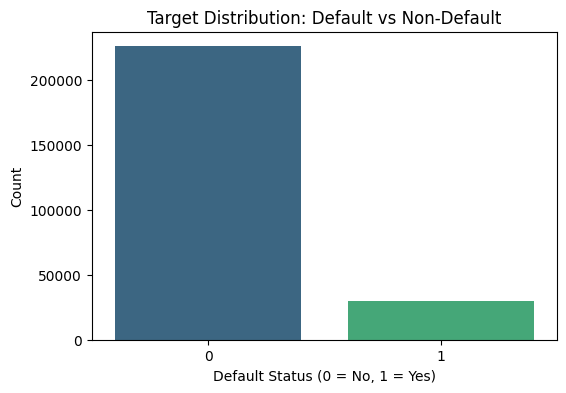

In [ ]:
# Target distribution
target_counts = df['Default'].value_counts()
target_pct = df['Default'].value_counts(normalize=True) * 100

print(f"Non-Default (0): {target_counts[0]} ({target_pct[0]:.2f}%)")
print(f"Default (1):     {target_counts[1]} ({target_pct[1]:.2f}%)")

# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Default', palette='viridis')
plt.title('Target Distribution: Default vs Non-Default')
plt.xlabel('Default Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1249/2204049891.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=col, y='Default', ax=axes[i], ci=None, palette='mako')
/tmp/ipykernel_1249/2204049891.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Default', ax=axes[i], ci=None, palette='mako')
/tmp/ipykernel_1249/2204049891.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=col, y='Default', ax=axes[i], ci=None, palette='mako')
/tmp/ipykernel_1249/2204049891.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Default', ax=axes[i], ci=No

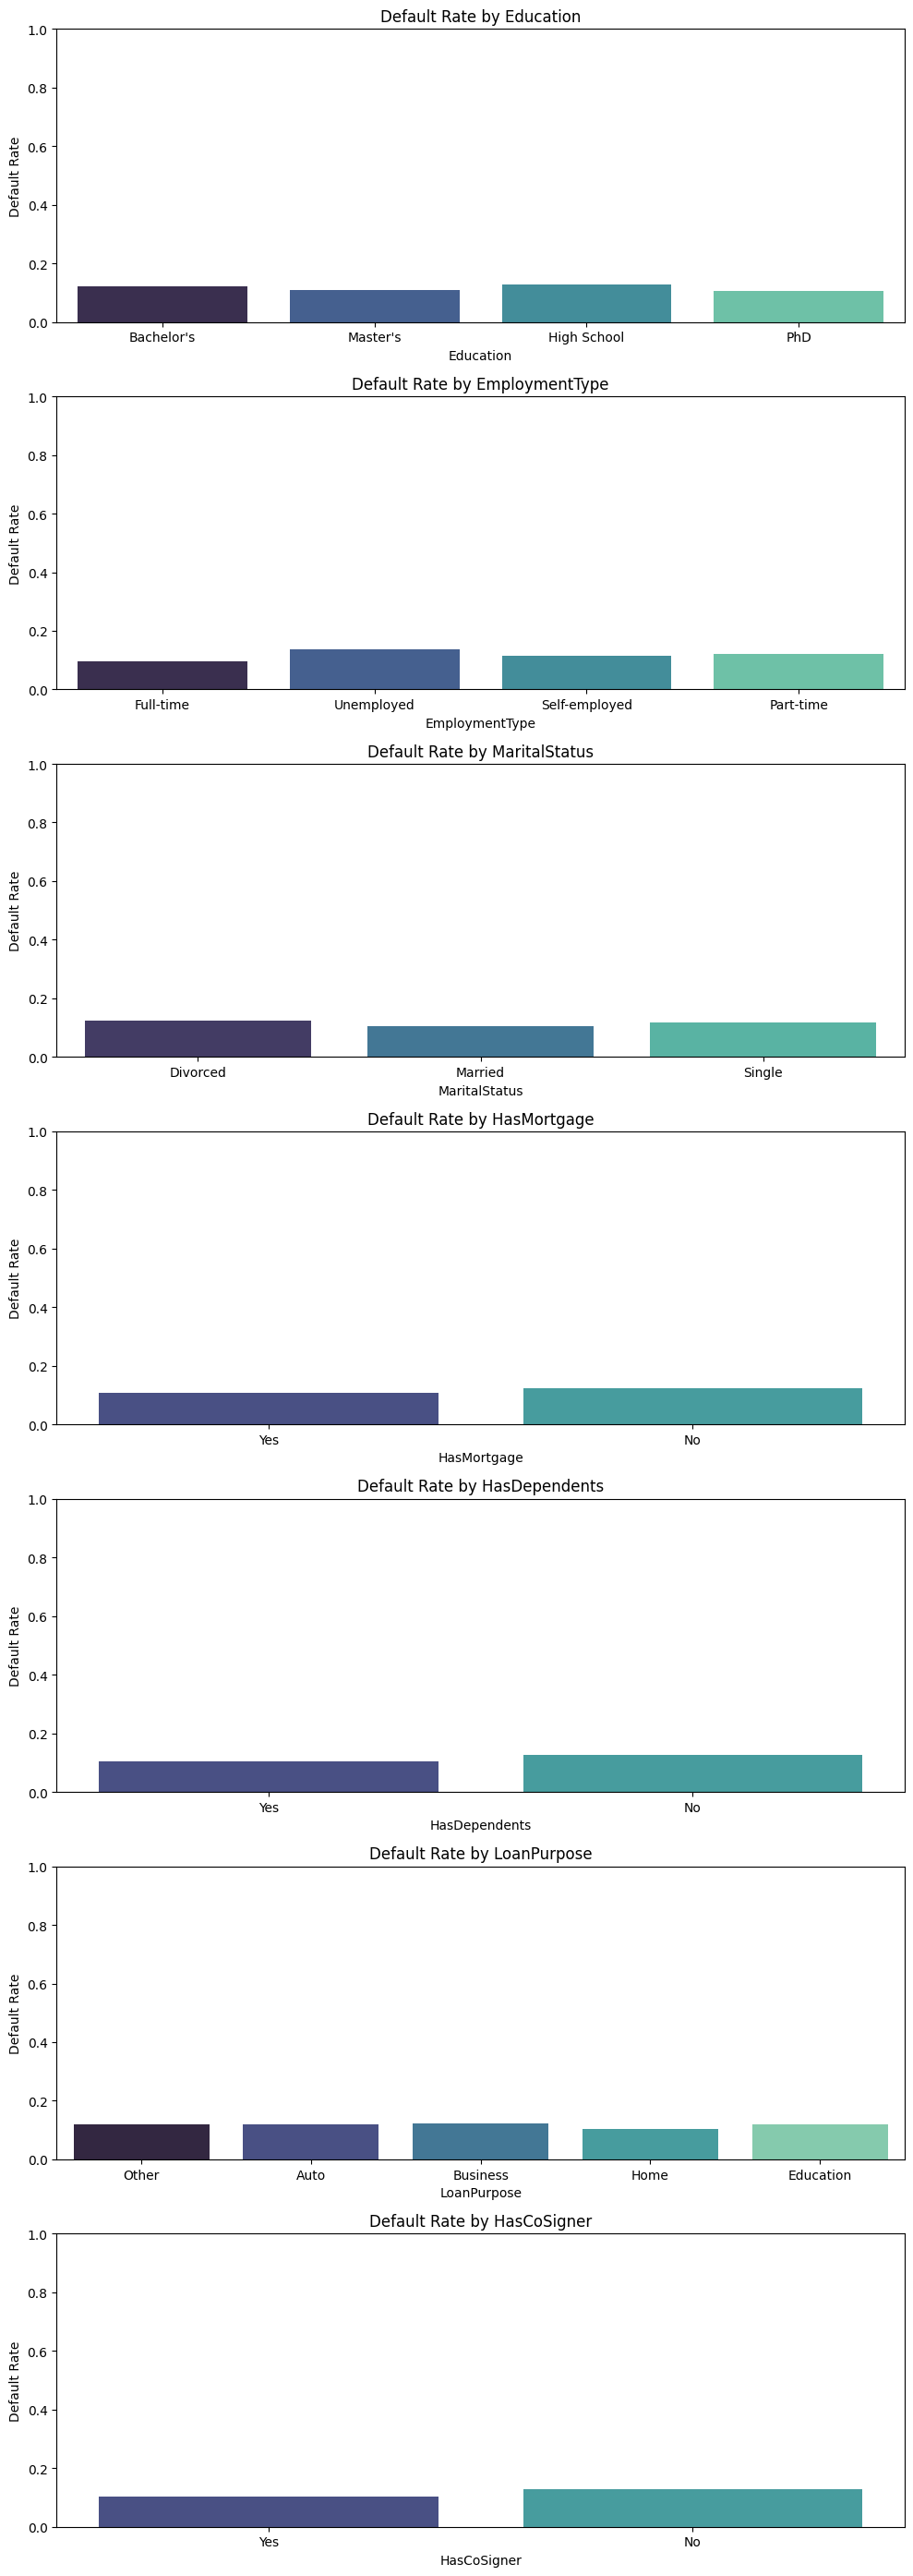

In [ ]:
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus',
            'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    sns.barplot(data=df, x=col, y='Default', ax=axes[i], ci=None, palette='mako')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1249/2587702721.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y=col, palette='Set2')
/tmp/ipykernel_1249/2587702721.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y=col, palette='Set2')
/tmp/ipykernel_1249/2587702721.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y=col, palette='Set2')
/tmp/ipykernel_1249/2587702721.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

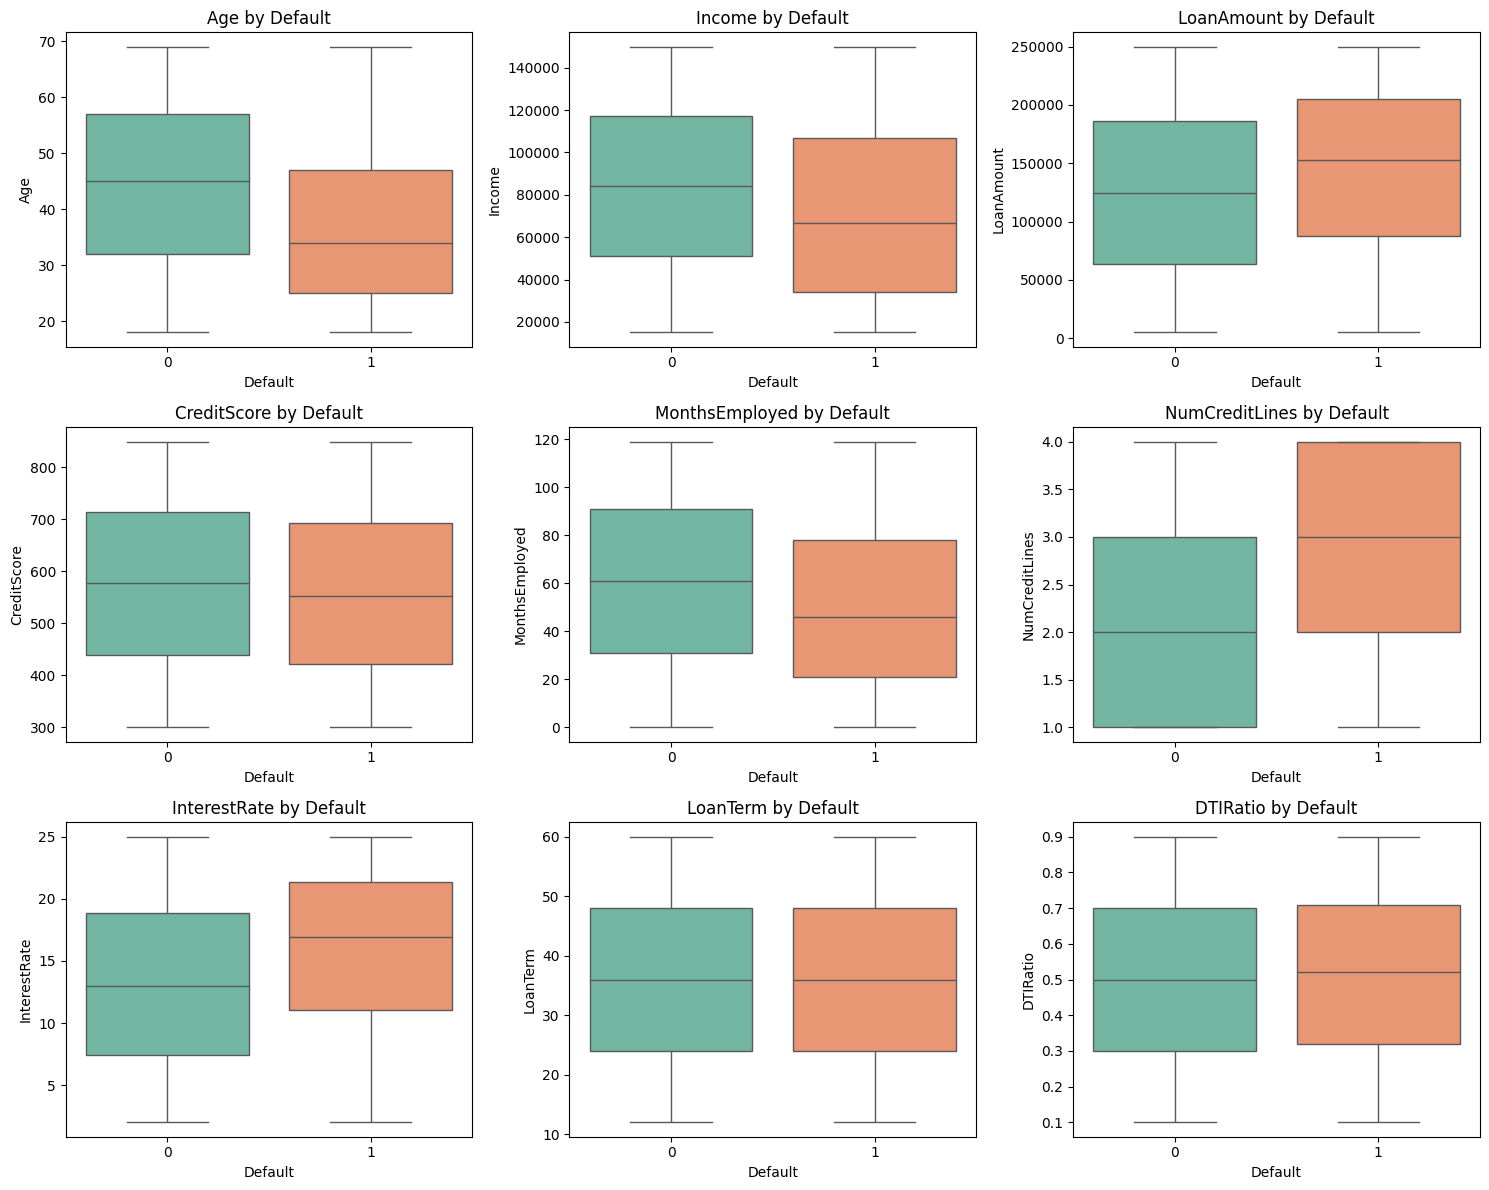

In [ ]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Default', y=col, palette='Set2')
    plt.title(f'{col} by Default')

plt.tight_layout()
plt.show()
## 0 - non default and 1 - default

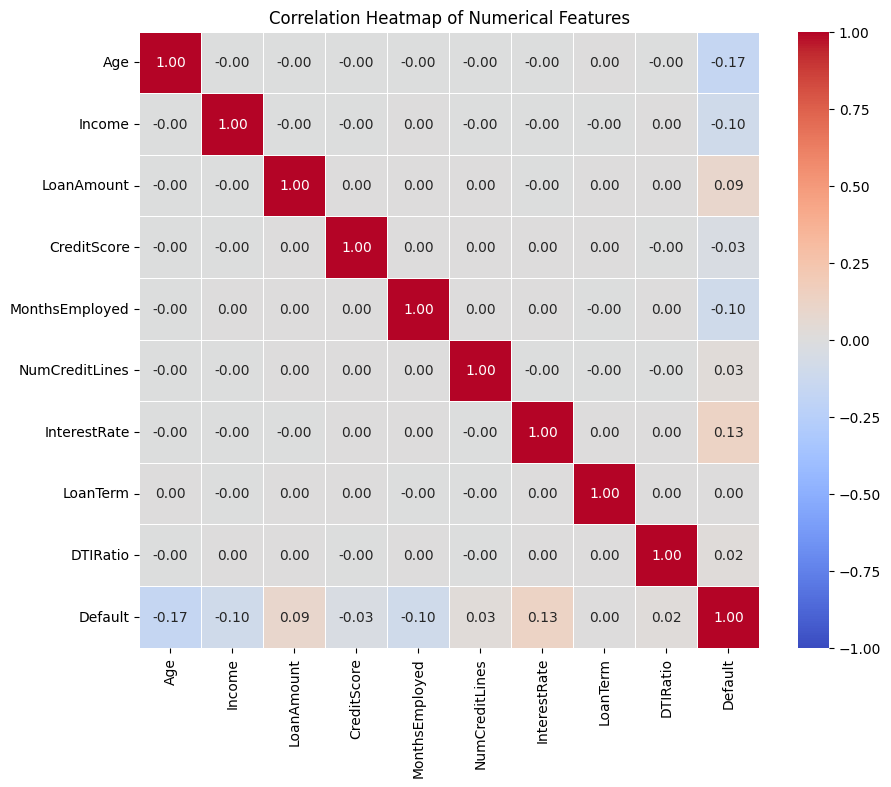


--- Correlation with Default Target ---


,Default
Default,1.000000
InterestRate,0.131273
LoanAmount,0.086659
NumCreditLines,0.028330
DTIRatio,0.019236
LoanTerm,0.000545
CreditScore,-0.034166
MonthsEmployed,-0.097374
Income,-0.099119
Age,-0.167783


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define list of numerical features including the target variable
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines', 'InterestRate',
            'LoanTerm', 'DTIRatio', 'Default']

# Calculate linear Pearson correlation
corr_matrix = df[num_cols].corr()

# 1. Plot complete Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 2. Extract and print sorted correlations specifically with the target variable 'Default'
print("\n--- Correlation with Default Target ---")
display(corr_matrix['Default'].sort_values(ascending=False))

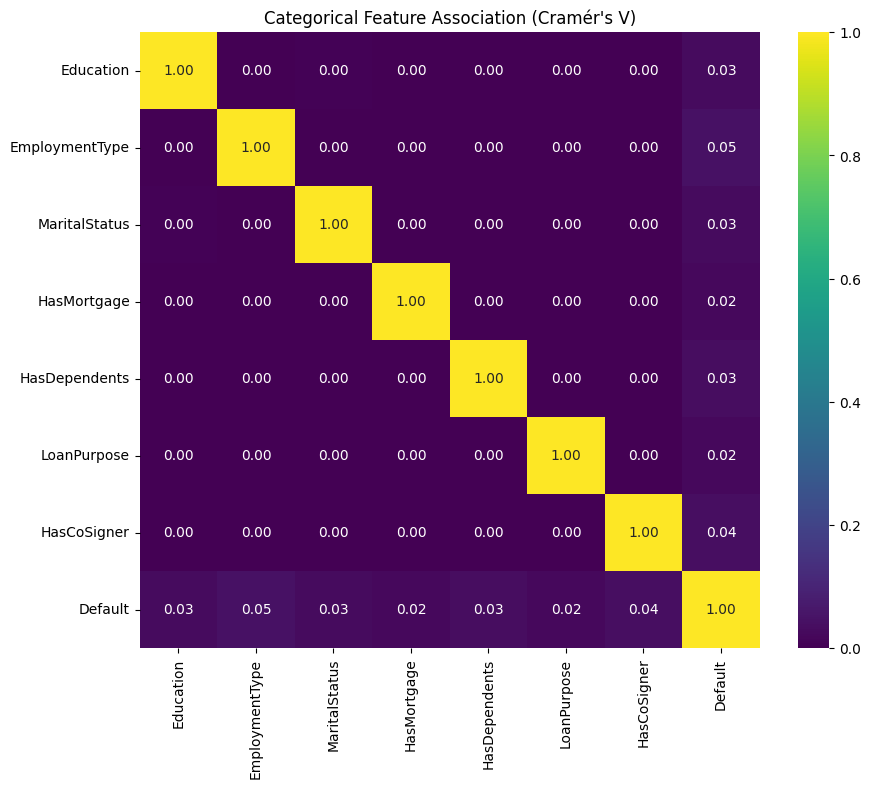


--- Categorical Association Strength with Default ---


,Default
Default,0.999981
EmploymentType,0.045419
HasCoSigner,0.039046
HasDependents,0.034609
Education,0.028747
MaritalStatus,0.027872
HasMortgage,0.022758
LoanPurpose,0.022031


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Define list of categorical features + target
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus',
            'HasMortgage', 'HasDependents', 'LoanPurpose',
            'HasCoSigner', 'Default']

def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Initialize empty matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

# Calculate Cramér's V for every pair
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap='viridis', vmin=0, vmax=1)
plt.title("Categorical Feature Association (Cramér's V)")
plt.show()

# Print ranking with Default target
print("\n--- Categorical Association Strength with Default ---")
display(cramers_matrix['Default'].sort_values(ascending=False))

In [ ]:
# Calculate counts and percentages
counts = df['Default'].value_counts()
percentages = df['Default'].value_counts(normalize=True) * 100

# Combine into a summary DataFrame
summary_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})

# Rename index for clarity
summary_df.index = summary_df.index.map({0: 'Non-Defaulter (0)', 1: 'Defaulter (1)'})

print("--- Default Class Counts & Percentages ---")
display(summary_df)

--- Default Class Counts & Percentages ---


,Count,Percentage (%)
Default,,
Non-Defaulter (0),225694,88.39
Defaulter (1),29653,11.61


In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. Separate features and target
X = df.drop(columns=['LoanID', 'Default'])
y = df['Default']

# 2. One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. 80% Development Set / 20% Holdout Test Set Split
X_dev, X_test, y_dev, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Calculate scale_pos_weight for imbalance (~7.61)
scale_pos_weight = (len(y_dev) - sum(y_dev)) / sum(y_dev)

# 5. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=0)
}

# 6. Stratified 5-Fold Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1']

cv_results = []

for name, model in models.items():
    print(f"Evaluating {name} with 5-Fold CV...")
    scores = cross_validate(model, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": np.mean(scores['test_roc_auc']),
        "Std ROC-AUC": np.std(scores['test_roc_auc']),
        "Mean F1-Score": np.mean(scores['test_f1']),
        "Std F1-Score": np.std(scores['test_f1'])
    })

# Display Results
results_df = pd.DataFrame(cv_results).sort_values(by="Mean ROC-AUC", ascending=False)
display(results_df)

Evaluating Logistic Regression with 5-Fold CV...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, recall_score, precision_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Instantiate default models with class imbalance handling
models = {
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=0),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
}

test_results = []

# 2. Fit each model on X_dev and evaluate on X_test
for name, model in models.items():
    print(f"Training {name} on X_dev...")
    model.fit(X_dev, y_dev)

    # Predict class and probabilities on unseen test set
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate performance metrics
    test_results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "F1-Score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    })

# 3. Format and display comparison table
test_df = pd.DataFrame(test_results).sort_values(by="ROC-AUC", ascending=False)
print("\n================ FINAL TEST SET RESULTS (WITHOUT OPTUNA) ================")
display(test_df)

Training LightGBM on X_dev...
Training CatBoost on X_dev...
Training XGBoost on X_dev...
Training Random Forest on X_dev...

================ FINAL TEST SET RESULTS (WITHOUT OPTUNA) ================


,Model,ROC-AUC,F1-Score,Recall,Precision,Accuracy
0,LightGBM,0.756580,0.339435,0.684707,0.225649,0.690503
3,Random Forest,0.751800,0.361572,0.547631,0.269880,0.775406
1,CatBoost,0.748513,0.341789,0.639521,0.233214,0.713942
2,XGBoost,0.741237,0.337738,0.627044,0.231109,0.714412


Optimal Threshold (Max F1): 0.6343
Best Training F1-Score:    0.3890


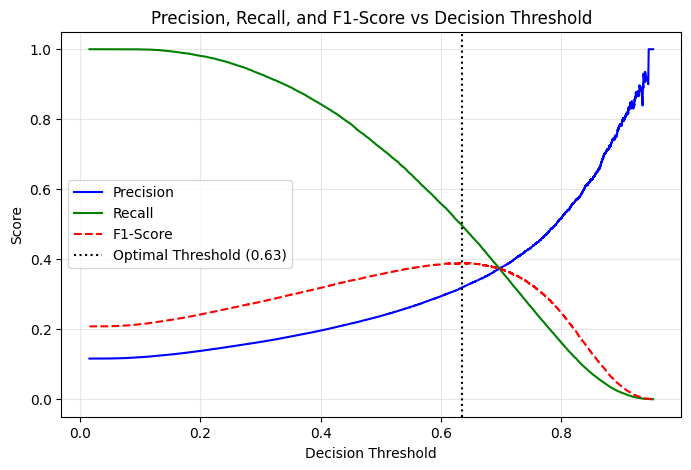

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

# 1. Get predicted probabilities on X_dev using your best model (LightGBM)
best_model = models["LightGBM"]
y_proba_dev = best_model.predict_proba(X_dev)[:, 1]

# 2. Compute Precision, Recall, and Thresholds
precisions, recalls, thresholds = precision_recall_curve(y_dev, y_proba_dev)

# 3. Calculate F1-Score for every threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 4. Find the threshold that maximizes F1-Score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold (Max F1): {best_threshold:.4f}")
print(f"Best Training F1-Score:    {best_f1:.4f}")

# 5. Plot Precision-Recall Trade-off vs Threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='red', linestyle='--')
plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Optimal Threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Get test set probabilities
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Default predictions (Threshold = 0.50)
y_pred_default = (y_proba_test >= 0.50).astype(int)

# Tuned predictions (Optimal Threshold)
y_pred_tuned = (y_proba_test >= best_threshold).astype(int)

# Compare Results
print("=================== BEFORE TUNING (Threshold = 0.50) ===================")
print(classification_report(y_test, y_pred_default, digits=4))

print(f"\n=================== AFTER TUNING (Threshold = {best_threshold:.4f}) ===================")
print(classification_report(y_test, y_pred_tuned, digits=4))

NameError: name 'best_model' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import ks_2samp

# 1. Calculate Probabilities on Test Set
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC-AUC & Gini Coefficient
roc_auc = roc_auc_score(y_test, y_proba_test)
gini = 2 * roc_auc - 1

# 3. Calculate PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_proba_test)

# 4. Calculate K-S Statistic
defaulters_proba = y_proba_test[y_test == 1]
non_defaulters_proba = y_proba_test[y_test == 0]
ks_stat, p_value = ks_2samp(defaulters_proba, non_defaulters_proba)

print("================ RESUME SCORECARD METRICS ================")
print(f"ROC-AUC Score:      {roc_auc:.4f}")
print(f"Gini Coefficient:   {gini * 100:.2f}%")
print(f"K-S Statistic:      {ks_stat * 100:.2f}%")
print(f"PR-AUC Score:       {pr_auc:.4f}")

================ RESUME SCORECARD METRICS ================
ROC-AUC Score:      0.7566
Gini Coefficient:   51.32%
K-S Statistic:      37.74%
PR-AUC Score:       0.3286


In [ ]:
import os

# Define export directory
export_dir = "/content/drive/MyDrive/loan_default_project"

# Save split feature sets and targets
X_dev.to_csv(os.path.join(export_dir, "X_dev.csv"), index=False)
X_test.to_csv(os.path.join(export_dir, "X_test.csv"), index=False)
y_dev.to_csv(os.path.join(export_dir, "y_dev.csv"), index=False)
y_test.to_csv(os.path.join(export_dir, "y_test.csv"), index=False)

print("✅ All checkpoints saved successfully to Google Drive!")

✅ All checkpoints saved successfully to Google Drive!


In [ ]:
import pandas as pd

export_dir = "/content/drive/MyDrive/loan_default_project"

# Load preprocessed datasets
X_dev = pd.read_csv(f"{export_dir}/X_dev.csv")
X_test = pd.read_csv(f"{export_dir}/X_test.csv")
y_dev = pd.read_csv(f"{export_dir}/y_dev.csv").values.ravel()
y_test = pd.read_csv(f"{export_dir}/y_test.csv").values.ravel()

# Recalculate scale_pos_weight
scale_pos_weight = (len(y_dev) - sum(y_dev)) / sum(y_dev)

print("🚀 Datasets loaded instantly! Ready for Optuna.")

🚀 Datasets loaded instantly! Ready for Optuna.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

export_dir = "/content/drive/MyDrive/loan_default_project"

X_dev = pd.read_csv(f"{export_dir}/X_dev.csv")
X_test = pd.read_csv(f"{export_dir}/X_test.csv")
y_dev = pd.read_csv(f"{export_dir}/y_dev.csv").values.ravel()
y_test = pd.read_csv(f"{export_dir}/y_test.csv").values.ravel()

scale_pos_weight = (len(y_dev) - sum(y_dev)) / sum(y_dev)
print("Datasets loaded instantly! Ready for Optuna.")

Datasets loaded instantly! Ready for Optuna.


In [ ]:
import torch

# Check if PyTorch detects a GPU
if torch.cuda.is_available():
    print(f"✅ GPU is active: {torch.cuda.get_device_name(0)}")
else:
    print("❌ No GPU found. Currently running on CPU.")

✅ GPU is active: Tesla T4


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [ ]:
!pip install optuna -q

import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Suppress Optuna logging noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. Select the Model Algorithm as a hyperparameter
    classifier_name = trial.suggest_categorical(
        "classifier", ["LightGBM", "XGBoost", "CatBoost", "RandomForest"]
    )

    # Stratified 5-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 2. Define Model Hyperparameter Search Spaces
    if classifier_name == "LightGBM":
        params = {
            "n_estimators": trial.suggest_int("lgb_n_estimators", 100, 400, step=50),
            "max_depth": trial.suggest_int("lgb_max_depth", 3, 10),
            "num_leaves": trial.suggest_int("lgb_num_leaves", 15, 127),
            "learning_rate": trial.suggest_float("lgb_learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("lgb_subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("lgb_colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": scale_pos_weight,
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1
        }
        model = LGBMClassifier(**params)

    elif classifier_name == "XGBoost":
        params = {
            "n_estimators": trial.suggest_int("xgb_n_estimators", 100, 400, step=50),
            "max_depth": trial.suggest_int("xgb_max_depth", 3, 10),
            "learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": scale_pos_weight,
            "tree_method": "hist",
            "device": "cuda",
            "random_state": 42,
            "eval_metric": "logloss"
        }
        model = XGBClassifier(**params)

    elif classifier_name == "CatBoost":
        params = {
            "iterations": trial.suggest_int("cb_iterations", 100, 400, step=50),
            "depth": trial.suggest_int("cb_depth", 3, 10),
            "learning_rate": trial.suggest_float("cb_learning_rate", 0.01, 0.2, log=True),
            "l2_leaf_reg": trial.suggest_float("cb_l2_leaf_reg", 1e-3, 10.0, log=True),
            "auto_class_weights": "Balanced",  # <--- Replaced scale_pos_weight with this
            "task_type": "GPU",
            "random_seed": 42,
            "verbose": 0
        }
        model = CatBoostClassifier(**params)

    else:  # RandomForest
        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators", 100, 300, step=50),
            "max_depth": trial.suggest_int("rf_max_depth", 8, 20),
            "min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("rf_min_samples_leaf", 1, 5),
            "max_features": trial.suggest_categorical("rf_max_features", ["sqrt", "log2"]),
            "class_weight": "balanced",  # Handles imbalanced target
            "random_state": 42,
            "n_jobs": -1
        }
        model = RandomForestClassifier(**params)

    # 3. Evaluate using 5-Fold Stratified CV on ROC-AUC
    scores = cross_val_score(model, X_dev, y_dev, cv=skf, scoring="roc_auc", n_jobs=1)

    return scores.mean()

# 4. Execute Optuna Search
print("🚀 Starting Optuna Multi-Algorithm Search (Including Random Forest)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, timeout=600)

# 5. Output Results
print("\n================ OPTUNA SEARCH COMPLETED ================")
print(f"Best Trial ROC-AUC Score: {study.best_value:.4f}")
print(f"Winning Algorithm:        {study.best_params['classifier']}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

🚀 Starting Optuna Multi-Algorithm Search (Including Random Forest)...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [16:05:00] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



================ OPTUNA SEARCH COMPLETED ================
Best Trial ROC-AUC Score: 0.7519
Winning Algorithm:        XGBoost

Best Hyperparameters:
  classifier: XGBoost
  xgb_n_estimators: 200
  xgb_max_depth: 5
  xgb_learning_rate: 0.02870609675941067
  xgb_subsample: 0.8028321440925615
  xgb_colsample_bytree: 0.7914137914938398


<Axes: >

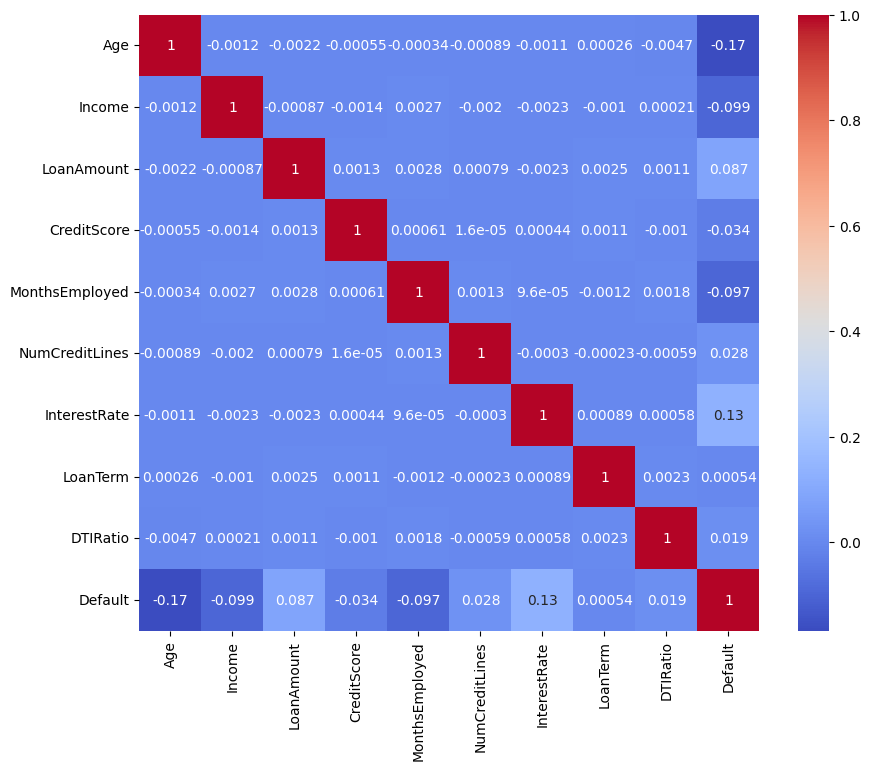

In [ ]:
numerical_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines', 'InterestRate',
            'LoanTerm', 'DTIRatio', 'Default']

corr = df[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

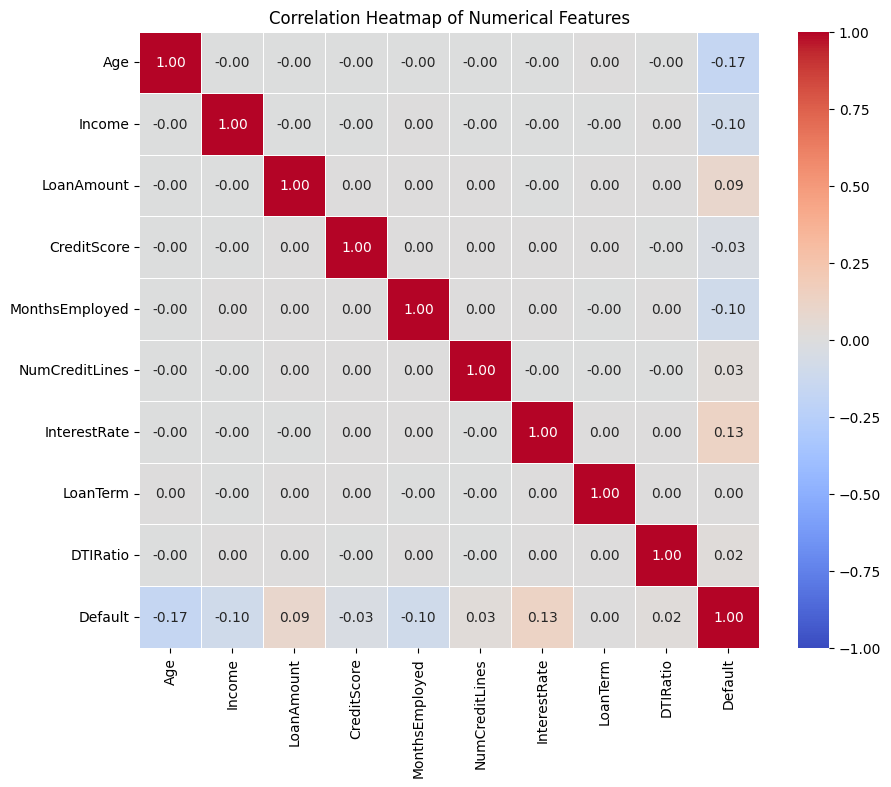


--- Correlation with Default Target ---


,Default
Default,1.000000
InterestRate,0.131273
LoanAmount,0.086659
NumCreditLines,0.028330
DTIRatio,0.019236
LoanTerm,0.000545
CreditScore,-0.034166
MonthsEmployed,-0.097374
Income,-0.099119
Age,-0.167783


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define list of numerical features including the target variable
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines', 'InterestRate',
            'LoanTerm', 'DTIRatio', 'Default']

# Calculate linear Pearson correlation
corr_matrix = df[num_cols].corr()

# 1. Plot complete Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 2. Extract and print sorted correlations specifically with the target variable 'Default'
print("\n--- Correlation with Default Target ---")
display(corr_matrix['Default'].sort_values(ascending=False))

In [ ]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from scipy.stats import ks_2samp

# 1. Retrieve Winning Classifier and Parameters from Optuna
winning_algo = study.best_params["classifier"]
best_params = study.best_params.copy()
best_params.pop("classifier")  # Remove classifier name key

print(f"🏆 Retraining Final Optimized Model: {winning_algo}...")

# 2. Instantiate Model with Best Parameters
if winning_algo == "LightGBM":
    # Format params for LGBM
    lgb_params = {k.replace("lgb_", ""): v for k, v in best_params.items() if k.startswith("lgb_")}
    final_model = LGBMClassifier(**lgb_params, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1)

elif winning_algo == "XGBoost":
    xgb_params = {k.replace("xgb_", ""): v for k, v in best_params.items() if k.startswith("xgb_")}
    final_model = XGBClassifier(**xgb_params, scale_pos_weight=scale_pos_weight, tree_method="hist", device="cuda", random_state=42, eval_metric="logloss")

elif winning_algo == "CatBoost":
    cb_params = {k.replace("cb_", ""): v for k, v in best_params.items() if k.startswith("cb_")}
    final_model = CatBoostClassifier(**cb_params, auto_class_weights="Balanced", task_type="GPU", random_seed=42, verbose=0)

else:  # RandomForest
    rf_params = {k.replace("rf_", ""): v for k, v in best_params.items() if k.startswith("rf_")}
    final_model = RandomForestClassifier(**rf_params, class_weight="balanced", random_state=42, n_jobs=-1)

# 3. Train on FULL X_dev
final_model.fit(X_dev, y_dev)

# 4. Predict Probabilities on Test Set
y_proba_final = final_model.predict_proba(X_test)[:, 1]

# 5. Apply Tuned Decision Threshold (0.6343)
opt_threshold = 0.6343
y_pred_final = (y_proba_final >= opt_threshold).astype(int)

# 6. Calculate Final Banking Scorecard Metrics
auc_score = roc_auc_score(y_test, y_proba_final)
gini_score = 2 * auc_score - 1
ks_stat, _ = ks_2samp(y_proba_final[y_test == 1], y_proba_final[y_test == 0])
pr_auc = average_precision_score(y_test, y_proba_final)

print("\n================ FINAL OPTIMIZED SCORECARD PERFORMANCE ================")
print(f"Winning Architecture: {winning_algo}")
print(f"Test ROC-AUC:         {auc_score:.4f}")
print(f"Test Gini Score:      {gini_score * 100:.2f}%")
print(f"Test K-S Statistic:  {ks_stat * 100:.2f}%")
print(f"Test PR-AUC:          {pr_auc:.4f}")
print("========================================================================\n")

print(f"Classification Report (at Threshold = {opt_threshold}):")
print(classification_report(y_test, y_pred_final, digits=4))

🏆 Retraining Final Optimized Model: XGBoost...

================ FINAL OPTIMIZED SCORECARD PERFORMANCE ================
Winning Architecture: XGBoost
Test ROC-AUC:         0.7573
Test Gini Score:      51.45%
Test K-S Statistic:  38.12%
Test PR-AUC:          0.3305

Classification Report (at Threshold = 0.6343):
              precision    recall  f1-score   support

           0     0.9241    0.8693    0.8959     45139
           1     0.3147    0.4568    0.3727      5931

    accuracy                         0.8214     51070
   macro avg     0.6194    0.6630    0.6343     51070
weighted avg     0.8534    0.8214    0.8351     51070



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from scipy.stats import ks_2samp
from xgboost import XGBClassifier

print("⚡ Step 1: Engineering Advanced Risk Features...")

# 1. Feature Engineering
df_fe = df.copy()

# Derived Financial Calculations
df_fe['MonthlyIncome'] = df_fe['Income'] / 12
df_fe['MonthlyDebtPayment'] = df_fe['MonthlyIncome'] * df_fe['DTIRatio']
df_fe['EstimatedLoanPayment'] = df_fe['LoanAmount'] / df_fe['LoanTerm']

# High-Signal Financial & Risk Ratios
df_fe['PaymentToIncomeRatio'] = df_fe['EstimatedLoanPayment'] / (df_fe['MonthlyIncome'] + 1e-5)
df_fe['IncomeToLoanRatio'] = df_fe['Income'] / (df_fe['LoanAmount'] + 1e-5)
df_fe['EmploymentToAgeRatio'] = df_fe['MonthsEmployed'] / (df_fe['Age'] * 12)
df_fe['CreditLinesPerYear'] = df_fe['NumCreditLines'] / ((df_fe['Age'] - 18).clip(lower=1))

# Drop LoanID
if 'LoanID' in df_fe.columns:
    df_fe = df_fe.drop(columns=['LoanID'])

# One-Hot Encode Categorical Columns
cat_features = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
df_fe = pd.get_dummies(df_fe, columns=cat_features, drop_first=True)

# Re-split Development (Dev) and Test Sets with same random seed
X_fe = df_fe.drop(columns=['Default'])
y_fe = df_fe['Default']

X_dev_fe, X_test_fe, y_dev_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.20, random_state=42, stratify=y_fe
)

print(f"Features expanded from {X_dev.shape[1]} to {X_dev_fe.shape[1]} features!")

print("\n🚀 Step 2: Retraining Tuned XGBoost with Feature Set...")

# Retrain XGBoost with Optuna parameters on new feature set
xgb_base = XGBClassifier(
    **{k.replace("xgb_", ""): v for k, v in best_params.items() if k.startswith("xgb_")},
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device="cuda",
    random_state=42,
    eval_metric="logloss"
)
xgb_base.fit(X_dev_fe, y_dev_fe)

# 3. Probability Calibration via Isotonic Regression
print("\n🎯 Step 3: Calibrating Risk Probabilities...")
calibrated_xgb = CalibratedClassifierCV(xgb_base, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_dev_fe, y_dev_fe)

y_proba_boosted = calibrated_xgb.predict_proba(X_test_fe)[:, 1]

# 4. Optimal Profit-Based Decision Threshold Search
best_f1 = 0
best_thresh = 0.5

for thresh in np.arange(0.10, 0.90, 0.01):
    preds = (y_proba_boosted >= thresh).astype(int)
    # Target F1 specifically for Default class (1)
    report = classification_report(y_test_fe, preds, output_dict=True)
    f1 = report['1']['f1-score']
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

# 5. Evaluate Final Metrics
auc_score = roc_auc_score(y_test_fe, y_proba_boosted)
gini_score = 2 * auc_score - 1
ks_stat, _ = ks_2samp(y_proba_boosted[y_test_fe == 1], y_proba_boosted[y_test_fe == 0])
pr_auc = average_precision_score(y_test_fe, y_proba_boosted)

print("\n================ 🚀 UPGRADED MODEL SCORECARD ================")
print(f"Test ROC-AUC:         {auc_score:.4f}")
print(f"Test Gini Score:      {gini_score * 100:.2f}%")
print(f"Test K-S Statistic:  {ks_stat * 100:.2f}%")
print(f"Test PR-AUC:          {pr_auc:.4f}")
print(f"Optimal Threshold:    {best_thresh:.4f}")
print("==============================================================\n")

y_pred_boosted = (y_proba_boosted >= best_thresh).astype(int)
print(f"Classification Report (at Threshold = {best_thresh:.4f}):")
print(classification_report(y_test_fe, y_pred_boosted, digits=4))

⚡ Step 1: Engineering Advanced Risk Features...
Features expanded from 24 to 31 features!

🚀 Step 2: Retraining Tuned XGBoost with Feature Set...

🎯 Step 3: Calibrating Risk Probabilities...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



================ 🚀 UPGRADED MODEL SCORECARD ================
Test ROC-AUC:         0.7585
Test Gini Score:      51.70%
Test K-S Statistic:  38.19%
Test PR-AUC:          0.3251
Optimal Threshold:    0.1800

Classification Report (at Threshold = 0.1800):
              precision    recall  f1-score   support

           0     0.9261    0.8590    0.8913     45139
           1     0.3081    0.4780    0.3747      5931

    accuracy                         0.8147     51070
   macro avg     0.6171    0.6685    0.6330     51070
weighted avg     0.8543    0.8147    0.8313     51070



In [ ]:
import joblib
import os

# 1. Save calibrated final model artifact
model_path = os.path.join(PROJECT_DIR, "final_calibrated_xgb_model.pkl")
joblib.dump(calibrated_xgb, model_path)

# 2. Save feature list to ensure correct column order for future predictions
features_path = os.path.join(PROJECT_DIR, "model_features.pkl")
joblib.dump(X_dev_fe.columns.tolist(), features_path)

print(f"✅ Final Upgraded Model saved successfully to:\n{model_path}")
print(f"✅ Feature column list saved successfully to:\n{features_path}")

✅ Final Upgraded Model saved successfully to:
/content/drive/MyDrive/loan_default_project/final_calibrated_xgb_model.pkl
✅ Feature column list saved successfully to:
/content/drive/MyDrive/loan_default_project/model_features.pkl


In [ ]:
import joblib
import os

# 1. Define paths to saved model artifacts
model_path = os.path.join(PROJECT_DIR, "final_calibrated_xgb_model.pkl")
features_path = os.path.join(PROJECT_DIR, "model_features.pkl")

# 2. Load model and feature names
calibrated_xgb = joblib.load(model_path)
model_features = joblib.load(features_path)

print("✅ Calibrated XGBoost Model loaded successfully!")
print(f" Total Features: {len(model_features)}")

✅ Calibrated XGBoost Model loaded successfully!
 Total Features: 31


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [18:44:36] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


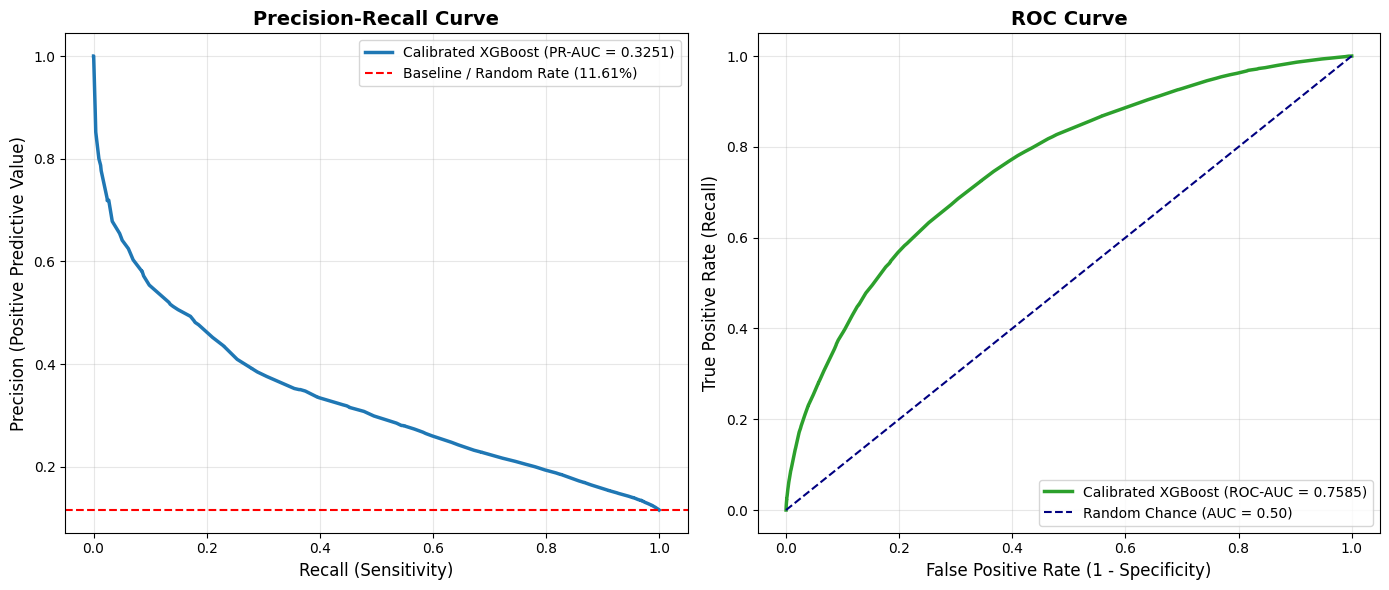

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score, roc_auc_score

# 1. Re-engineer features from raw df to recreate test set
df_fe = df.copy()

# Derived Financial Calculations
df_fe['MonthlyIncome'] = df_fe['Income'] / 12
df_fe['MonthlyDebtPayment'] = df_fe['MonthlyIncome'] * df_fe['DTIRatio']
df_fe['EstimatedLoanPayment'] = df_fe['LoanAmount'] / df_fe['LoanTerm']

# High-Signal Financial & Risk Ratios
df_fe['PaymentToIncomeRatio'] = df_fe['EstimatedLoanPayment'] / (df_fe['MonthlyIncome'] + 1e-5)
df_fe['IncomeToLoanRatio'] = df_fe['Income'] / (df_fe['LoanAmount'] + 1e-5)
df_fe['EmploymentToAgeRatio'] = df_fe['MonthsEmployed'] / (df_fe['Age'] * 12)
df_fe['CreditLinesPerYear'] = df_fe['NumCreditLines'] / ((df_fe['Age'] - 18).clip(lower=1))

if 'LoanID' in df_fe.columns:
    df_fe = df_fe.drop(columns=['LoanID'])

cat_features = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
df_fe = pd.get_dummies(df_fe, columns=cat_features, drop_first=True)

X_fe = df_fe[model_features]  # Ensure exact column order from loaded feature list
y_fe = df_fe['Default']

# Split to get exact same test split
_, X_test_fe, _, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.20, random_state=42, stratify=y_fe
)

# 2. Predict Probabilities using loaded calibrated_xgb model
y_proba_final = calibrated_xgb.predict_proba(X_test_fe)[:, 1]

# 3. Compute Metrics
precision, recall, _ = precision_recall_curve(y_test_fe, y_proba_final)
fpr, tpr, _ = roc_curve(y_test_fe, y_proba_final)

pr_auc = average_precision_score(y_test_fe, y_proba_final)
roc_auc = roc_auc_score(y_test_fe, y_proba_final)

# 4. Plot PR Curve and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Precision-Recall Curve ---
axes[0].plot(recall, precision, color='#1f77b4', lw=2.5, label=f'Calibrated XGBoost (PR-AUC = {pr_auc:.4f})')
axes[0].axhline(y=0.1161, color='red', linestyle='--', label='Baseline / Random Rate (11.61%)')
axes[0].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[0].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: ROC Curve ---
axes[1].plot(fpr, tpr, color='#2ca02c', lw=2.5, label=f'Calibrated XGBoost (ROC-AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Chance (AUC = 0.50)')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TypeError: can only concatenate list (not "Line2D") to list

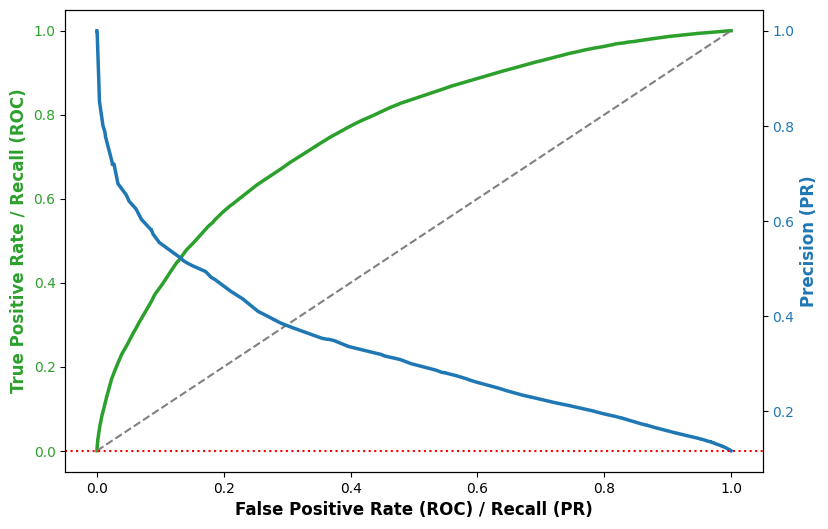

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score, roc_auc_score

# 1. Compute predictions and curves
y_proba_final = calibrated_xgb.predict_proba(X_test_fe)[:, 1]

precision, recall, _ = precision_recall_curve(y_test_fe, y_proba_final)
fpr, tpr, _ = roc_curve(y_test_fe, y_proba_final)

pr_auc = average_precision_score(y_test_fe, y_proba_final)
roc_auc = roc_auc_score(y_test_fe, y_proba_final)

# 2. Plot combined graph
fig, ax1 = plt.subplots(figsize=(9, 6))

# Left Y-Axis: ROC Curve (FPR vs TPR)
color1 = '#2ca02c'  # Green
ax1.set_xlabel('False Positive Rate (ROC) / Recall (PR)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Positive Rate / Recall (ROC)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(fpr, tpr, color=color1, lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.tick_params(axis='y', labelcolor=color1)

# Right Y-Axis: Precision-Recall Curve (Recall vs Precision)
ax2 = ax1.twinx()
color2 = '#1f77b4'  # Blue
ax2.set_ylabel('Precision (PR)', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(recall, precision, color=color2, lw=2.5, linestyle='-', label=f'PR Curve (PR-AUC = {pr_auc:.4f})')
ax2.tick_params(axis='y', labelcolor=color2)

# Reference Lines
line3 = ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', label='ROC Random Baseline (0.50)')
line4 = ax2.axhline(y=0.1161, color='red', linestyle=':', label='PR Baseline Rate (11.61%)')

# Merge Legends into One Box
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10, framealpha=0.9)

plt.title('Combined ROC and Precision-Recall Evaluation Curve', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# 1. Generate probabilities using your loaded calibrated model
y_proba_boosted = calibrated_xgb.predict_proba(X_test_fe)[:, 1]

# 2. Force threshold for higher recall (~80% default detection)
custom_thresh = 0.06700
y_pred_high_recall = (y_proba_boosted >= custom_thresh).astype(int)

print(f"Classification Report (at High Recall Threshold = {custom_thresh}):")
print(classification_report(y_test_fe, y_pred_high_recall, digits=4))

Classification Report (at High Recall Threshold = 0.067):
              precision    recall  f1-score   support

           0     0.9621    0.4415    0.6053     45139
           1     0.1695    0.8678    0.2837      5931

    accuracy                         0.4910     51070
   macro avg     0.5658    0.6547    0.4445     51070
weighted avg     0.8701    0.4910    0.5679     51070



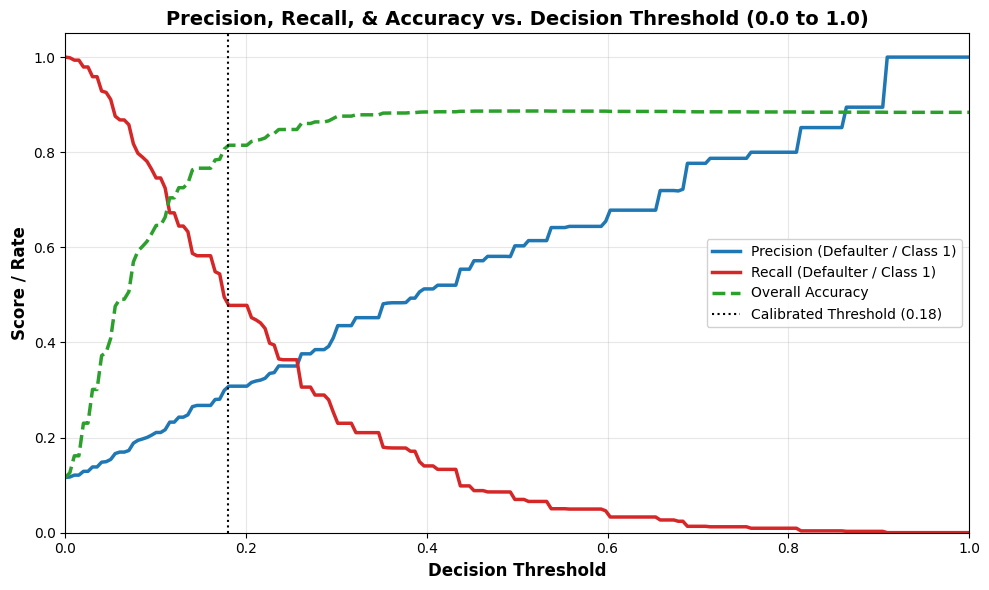

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score

# 1. Generate probabilities on test set
y_proba_final = calibrated_xgb.predict_proba(X_test_fe)[:, 1]

# 2. Define range of thresholds from 0.00 to 1.00
thresholds = np.linspace(0.0, 1.0, 200)

precisions = []
recalls = []
accuracies = []

# 3. Calculate metrics for each threshold
for thresh in thresholds:
    preds = (y_proba_final >= thresh).astype(int)

    precisions.append(precision_score(y_test_fe, preds, zero_division=0))
    recalls.append(recall_score(y_test_fe, preds, zero_division=0))
    accuracies.append(accuracy_score(y_test_fe, preds))

# 4. Plot Metrics vs. Decision Threshold (0.0 to 1.0)
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, label='Precision (Defaulter / Class 1)', color='#1f77b4', lw=2.5)
plt.plot(thresholds, recalls, label='Recall (Defaulter / Class 1)', color='#d62728', lw=2.5)
plt.plot(thresholds, accuracies, label='Overall Accuracy', color='#2ca02c', lw=2.5, linestyle='--')

# Highlight our calibrated threshold (0.1800)
opt_thresh = 0.1800
plt.axvline(x=opt_thresh, color='black', linestyle=':', label=f'Calibrated Threshold ({opt_thresh})')

plt.xlabel('Decision Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Score / Rate', fontsize=12, fontweight='bold')
plt.title('Precision, Recall, & Accuracy vs. Decision Threshold (0.0 to 1.0)', fontsize=14, fontweight='bold')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc='center right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 79.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score
import ipywidgets as widgets
from ipywidgets import interact

# Generate predictions once
y_proba_final = calibrated_xgb.predict_proba(X_test_fe)[:, 1]

# Interactive plotting function
def plot_3tier_risk(lower_thresh=0.12, band_width=0.12):
    upper_thresh = lower_thresh + band_width

    # Classify applicants
    def classify(p):
        if p < lower_thresh:
            return 'Approve'
        elif p < upper_thresh:
            return 'Manual Review'
        else:
            return 'Reject'

    decisions = pd.Series(y_proba_final).apply(classify)
    counts = decisions.value_counts(normalize=True) * 100

    # Metrics output
    print(f"🟢 Approved (Low Risk):    {counts.get('Approve', 0):.2f}%")
    print(f"🟡 Manual Review (Mid Risk): {counts.get('Manual Review', 0):.2f}%")
    print(f"🔴 Rejected (High Risk):   {counts.get('Reject', 0):.2f}%")
    print("=" * 50)

    # Plotting
    thresholds = np.linspace(0.0, 1.00, 200)
    precisions = [precision_score(y_test_fe, (y_proba_final >= t).astype(int), zero_division=0) for t in thresholds]
    recalls = [recall_score(y_test_fe, (y_proba_final >= t).astype(int), zero_division=0) for t in thresholds]
    accuracies = [accuracy_score(y_test_fe, (y_proba_final >= t).astype(int)) for t in thresholds]

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precisions, label='Precision (Defaulter)', color='#1f77b4', lw=2.5)
    plt.plot(thresholds, recalls, label='Recall (Defaulter)', color='#d62728', lw=2.5)
    plt.plot(thresholds, accuracies, label='Overall Accuracy', color='#2ca02c', lw=2.5, linestyle='--')

    # Color coded 3-Tier bands
    plt.axvspan(0.0, lower_thresh, color='green', alpha=0.15, label='Tier 1: Approve')
    plt.axvspan(lower_thresh, upper_thresh, color='gold', alpha=0.25, label='Tier 2: Manual Review')
    plt.axvspan(upper_thresh, 1.00, color='red', alpha=0.15, label='Tier 3: Reject')

    plt.axvline(x=lower_thresh, color='green', linestyle='--', lw=2)
    plt.axvline(x=upper_thresh, color='red', linestyle='--', lw=2)

    plt.xlabel('Default Probability Threshold', fontsize=11, fontweight='bold')
    plt.ylabel('Score / Rate', fontsize=11, fontweight='bold')
    plt.title('Interactive 3-Tier Decision Threshold Tuner', fontsize=13, fontweight='bold')
    plt.xlim(0.0, 1.01)
    plt.ylim(0.0, 1.01)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='center right', fontsize=9, framealpha=0.9)
    plt.show()

# Render interactive sliders in Colab!
interact(
    plot_3tier_risk,
    lower_thresh=widgets.FloatSlider(min=0.00, max=0.8, step=0.01, value=0.12, description='Approve Cutoff:'),
    band_width=widgets.FloatSlider(min=0.00, max=0.7, step=0.01, value=0.09, description='Review Band:')
);

interactive(children=(FloatSlider(value=0.12, description='Approve Cutoff:', max=0.8, step=0.01), FloatSlider(…

In [ ]:
import joblib
import os

# 1. Define output directory on Google Drive
save_dir = "/content/drive/MyDrive/loan_default_project"
os.makedirs(save_dir, exist_ok=True)

# 2. Define artifact paths
model_path = os.path.join(save_dir, "final_calibrated_xgb_model.pkl")
features_path = os.path.join(save_dir, "model_features.pkl")
config_path = os.path.join(save_dir, "model_config.pkl")

# 3. Save model and feature names
joblib.dump(calibrated_xgb, model_path)
joblib.dump(model_features, features_path)

# 4. Save optimal threshold metadata (3-tier cutoffs & metrics)
config_data = {
    'calibrated_threshold': 0.1800,
    'lower_approve_cutoff': 0.1200,
    'upper_reject_cutoff': 0.2400,
    'gini_score': 0.5170,
    'ks_stat': 0.3819,
    'roc_auc': 0.7585,
    'pr_auc': 0.3251
}
joblib.dump(config_data, config_path)

print("=" * 60)
print("🎉 ALL MODEL ARTIFACTS SAVED SUCCESSFULLY TO GOOGLE DRIVE!")
print("=" * 60)
print(f"📁 Directory:     {save_dir}")
print(f"🤖 Model File:     final_calibrated_xgb_model.pkl")
print(f"📋 Features File:  model_features.pkl (31 Engineered Features)")
print(f"⚙️ Metadata File:  model_config.pkl (Thresholds & Scores)")

🎉 ALL MODEL ARTIFACTS SAVED SUCCESSFULLY TO GOOGLE DRIVE!
📁 Directory:     /content/drive/MyDrive/loan_default_project
🤖 Model File:     final_calibrated_xgb_model.pkl
📋 Features File:  model_features.pkl (31 Engineered Features)
⚙️ Metadata File:  model_config.pkl (Thresholds & Scores)
